### **Diferencias entre `nn.Embedding` y `nn.Linear` en PyTorch**

En esta lección exploramos las diferencias entre dos clases ampliamente utilizadas en PyTorch: `nn.Embedding` y `nn.Linear`. El objetivo principal es comprender cómo funcionan ambas y por qué PyTorch las implementa como módulos independientes[cite: 1].

---

### **1. Diferencias en la Práctica**

A nivel operativo, ambas clases cumplen propósitos distintos dentro del pipeline de un modelo[cite: 1]:

* **`nn.Embedding` (Tabla de Búsqueda / Lookup Table):**
  * **Entrada:** Recibe índices enteros (IDs de tokens)[cite: 1].
  * **Operación:** Realiza una indexación directa en memoria ($O(1)$) para extraer la fila correspondiente[cite: 1].
  * **Uso:** Convertir representaciones discretas en vectores continuos a la entrada del modelo[cite: 1].

* **`nn.Linear` (Transformación Afín):**
  * **Entrada:** Recibe tensores de números flotantes[cite: 1].
  * **Operación:** Realiza una multiplicación matricial más un sesgo ($Y = X \cdot W^T + b$)[cite: 1].
  * **Uso:** Proyectar o transformar vectores de un espacio dimensional a otro a lo largo de la red[cite: 1].

---

### **2. La Estructura Fundamental: "Envoltorios" de PyTorch**

PyTorch suele ofrecer múltiples clases por **conveniencia de diseño y optimización computacional**[cite: 1]. Muchas de estas capas de alto nivel son, en realidad, simples **envoltorios (*wrappers*) alrededor de objetos más fundamentales de PyTorch**: la matriz de pesos aprendibles (`nn.Parameter` o `torch.Tensor`)[cite: 1].

* Tanto `nn.Embedding` como `nn.Linear` contienen en su interior una matriz de pesos flotantes con dimensiones `[filas, columnas]`[cite: 1].
* Si tomamos la matriz de pesos de una capa `nn.Embedding` y realizamos una multiplicación matricial con un vector *One-Hot*, el resultado matemático es idéntico al de una capa `nn.Linear` sin sesgo[cite: 1].

---

### **Conclusión**

En el fondo, **`nn.Embedding` y `nn.Linear` son el mismo tipo de objeto fundamental**: una matriz de parámetros entrenables[cite: 1].

No son idénticos en la práctica debido a cómo procesan sus entradas y optimizan la memoria, pero conceptualmente ambos son abstracciones construidas sobre la misma estructura base de PyTorch[cite: 1].

In [13]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [14]:
# suponer que las variables de vocab size son 5000 tokens
vocab_size = 5000

# Dimension de los embeddings en la raiz cuadrada de vocab_size
embed_dim = int(vocab_size**(1/2))
print(f'{vocab_size:,} tokens in the vocab, and {embed_dim} embedding dimensions.')

5,000 tokens in the vocab, and 70 embedding dimensions.


In [15]:
E = nn.Embedding(vocab_size, embed_dim) # Entrada [dim_entrada x dim_salida] (vocab_size x embed_dim)

In [16]:
L = nn.Linear(embed_dim, vocab_size) # Entrada [dim_entrada x dim_salida] -> Peso interno [salida x entrada]

In [17]:
print(E)

print(L)

Embedding(5000, 70)
Linear(in_features=70, out_features=5000, bias=True)


In [18]:
print(f'\nTamaño de la matriz de Embedding: {E.weight.shape}')
print(f'Tamaño de la matriz Lineal:        {L.weight.shape}')


Tamaño de la matriz de Embedding: torch.Size([5000, 70])
Tamaño de la matriz Lineal:        torch.Size([5000, 70])


Explorar los atributos

In [19]:
len(dir(E)), len(dir(L))

(129, 123)

In [20]:
dir(E)

['T_destination',
 '__annotations__',
 '__call__',
 '__class__',
 '__constants__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_apply',
 '_backward_hooks',
 '_backward_pre_hooks',
 '_buffers',
 '_call_impl',
 '_compiled_call_impl',
 '_fill_padding_idx_with_zero',
 '_forward_hooks',
 '_forward_hooks_always_called',
 '_forward_hooks_with_kwargs',
 '_forward_pre_hooks',
 '_forward_pre_hooks_with_kwargs',
 '_get_backward_hooks',
 '_get_backward_pre_hooks',
 '_get_name',
 '_is_full_backward_hook',
 '_load_from_state_dict',
 '_load_state_dict_post_hooks',
 '_load_state_dict_pre_hooks',
 '_maybe_warn_non_full_backward_hook',
 '_modules

In [21]:
# Atributos únicos en cada tipo
attrE = dir(E)
attrL = dir(L)

print('Atributos en Embedding que no están en Linear:')
for e in attrE:
  if e not in attrL:
    print('  ' + e)


print('\n\nAtributos en Linear que no están en Embedding:')
for l in attrL:
  if l not in attrE:
    print('  ' + l)

Atributos en Embedding que no están en Linear:
  _fill_padding_idx_with_zero
  embedding_dim
  from_pretrained
  max_norm
  norm_type
  num_embeddings
  padding_idx
  scale_grad_by_freq
  sparse


Atributos en Linear que no están en Embedding:
  bias
  in_features
  out_features


### Acceder a la informacion de los pesos

In [22]:
print(E.weight)

Parameter containing:
tensor([[-0.2345, -0.8887,  0.1550,  ...,  1.2599,  0.3007, -1.8104],
        [ 0.0919,  1.2216, -0.5260,  ...,  0.9038, -0.4144,  0.4044],
        [ 1.1547, -0.2817,  1.5675,  ..., -1.0649, -1.3066,  0.2812],
        ...,
        [-0.8116,  0.1305,  0.3704,  ...,  0.5800,  1.1486,  1.1493],
        [ 0.4582, -0.1032, -0.7227,  ..., -0.3574,  0.0565, -1.0799],
        [-0.3815,  0.0274,  0.2406,  ..., -0.2109, -2.3642, -0.5899]],
       requires_grad=True)


In [23]:
print(L.weight)

Parameter containing:
tensor([[-0.0595,  0.0490, -0.0891,  ..., -0.0636, -0.0550,  0.0948],
        [-0.0085,  0.0411, -0.0931,  ..., -0.0314,  0.0661, -0.0250],
        [ 0.0859, -0.0850, -0.0334,  ...,  0.1089, -0.0730, -0.0200],
        ...,
        [ 0.0724,  0.0674,  0.0607,  ..., -0.0797, -0.0963,  0.1042],
        [ 0.0245, -0.0534,  0.0429,  ...,  0.0117, -0.0956, -0.0636],
        [-0.0588, -0.0622,  0.0462,  ...,  0.0729, -0.0999,  0.0680]],
       requires_grad=True)


In [24]:
# Nos devolvera la matriz en una fila particular ejemplo (14) en el tensor

tokenidx = torch.tensor([14])
E(tokenidx) # bajo el capó emula un vector con One Hot Encoding (5.000 ceros donde el elemento 15 tiene un valor de 1 )

tensor([[ 3.4502e-02, -3.3968e-01,  1.0464e+00, -1.1909e-01,  1.9650e+00,
          8.9078e-01, -3.3327e-01, -6.0223e-01, -2.8372e-01,  3.3421e-01,
         -9.6070e-01,  5.7652e-01, -1.0562e+00,  3.2275e-01,  1.3669e+00,
          3.8244e-01, -3.5331e-01,  1.0297e+00,  6.3614e-01, -1.7263e+00,
          9.7625e-01, -8.9226e-01,  8.9080e-01,  2.9354e-02, -6.5866e-01,
          1.8462e+00,  3.3095e-01, -1.5257e-01,  4.0325e-01, -1.6389e+00,
          1.7678e+00,  1.6608e-01,  1.7425e+00, -2.8767e-01, -2.9627e-01,
         -9.3896e-01,  8.8875e-01,  8.3626e-02, -3.9474e-01,  7.9253e-01,
          3.4926e-01,  1.7187e+00,  1.2085e+00, -1.2050e-01,  1.0391e+00,
         -3.6002e-01, -3.6682e-01,  7.2479e-01, -1.2750e-03, -4.1575e-01,
         -1.1602e+00, -7.7012e-01,  2.9513e-01,  1.9688e-01,  1.2885e+00,
         -7.2680e-01, -2.9115e-01, -8.3980e-01,  2.6600e-01,  5.5180e-01,
         -2.0402e-02,  3.3601e-01, -2.8931e-01, -1.4773e-01,  1.7640e+00,
         -6.1664e-01,  8.8313e-01,  2.

In [25]:
# L(tokenidx) - si intentamos esta indexacion nos da error

L.weight[tokenidx, :]

tensor([[-0.0173, -0.0129,  0.0222,  0.0169,  0.1051, -0.0650,  0.0861, -0.0228,
          0.0061,  0.0520, -0.0744,  0.0567, -0.0269,  0.1056,  0.0409,  0.0685,
         -0.0719,  0.0439,  0.0787,  0.0654,  0.0840, -0.0374, -0.1169, -0.0469,
          0.0387,  0.0691, -0.0632,  0.1098,  0.0059, -0.0061,  0.0903,  0.1166,
         -0.0105,  0.0181, -0.1135, -0.0834, -0.1084, -0.1136, -0.0355,  0.0933,
         -0.0435, -0.0318, -0.0032, -0.0684,  0.0674,  0.1047, -0.1004,  0.0741,
          0.0887, -0.0732,  0.0066,  0.0881,  0.0155, -0.0220, -0.0320, -0.1108,
          0.1188, -0.0306,  0.0181,  0.0057,  0.1082,  0.0611,  0.0192,  0.0383,
         -0.0118,  0.0490,  0.0918,  0.0024, -0.0958, -0.0090]],
       grad_fn=<IndexBackward0>)

Estos pesos de nn.Embedding y nn.Linear no son los mismos porque se crean bajo instancias diferentes, así que no esperamos que sean iguales. Pero son equivalentes en el sentido de que estamos indexando la fila 14, por ejemplo, de la matriz. La cuestión es que, aunque la sintaxis sea diferente, podemos acceder a la misma información con dos enfoques ligeramente distintos.

In [26]:
# Codificación one-hot explícita con multiplicación vector-matriz
oneHotVect = torch.zeros(vocab_size,1)
oneHotVect[tokenidx] = 1

# # Como multiplicación vector-matriz
oneHotVect.t() @ L.weight

tensor([[-0.0173, -0.0129,  0.0222,  0.0169,  0.1051, -0.0650,  0.0861, -0.0228,
          0.0061,  0.0520, -0.0744,  0.0567, -0.0269,  0.1056,  0.0409,  0.0685,
         -0.0719,  0.0439,  0.0787,  0.0654,  0.0840, -0.0374, -0.1169, -0.0469,
          0.0387,  0.0691, -0.0632,  0.1098,  0.0059, -0.0061,  0.0903,  0.1166,
         -0.0105,  0.0181, -0.1135, -0.0834, -0.1084, -0.1136, -0.0355,  0.0933,
         -0.0435, -0.0318, -0.0032, -0.0684,  0.0674,  0.1047, -0.1004,  0.0741,
          0.0887, -0.0732,  0.0066,  0.0881,  0.0155, -0.0220, -0.0320, -0.1108,
          0.1188, -0.0306,  0.0181,  0.0057,  0.1082,  0.0611,  0.0192,  0.0383,
         -0.0118,  0.0490,  0.0918,  0.0024, -0.0958, -0.0090]],
       grad_fn=<MmBackward0>)

## Distribución de los pesos

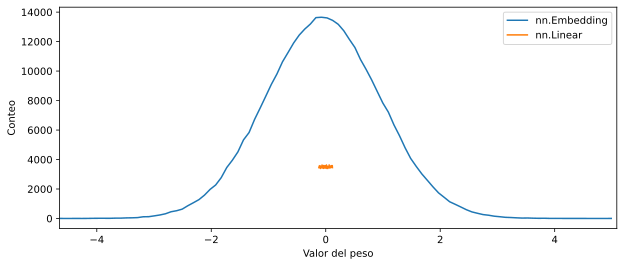

In [27]:
# Extraer histogramas para obtener distribuciones empíricas
Ey, Ex = np.histogram(E.weight.flatten().detach(), 100)
Ly, Lx = np.histogram(L.weight.flatten().detach(), 100)

plt.figure(figsize=(10, 4))
plt.plot(Ex[:-1], Ey, label='nn.Embedding')
plt.plot(Lx[:-1], Ly, label='nn.Linear')

plt.gca().set(
    xlim=[np.min(Ex), np.max(Ex)],
    xlabel='Valor del peso',
    ylabel='Conteo'
)
plt.legend()
plt.show()

In [28]:
print('*** Estadísticas de los pesos de nn.Linear ***\n')
print(f'Desviación estándar esperada (Kaiming): { np.sqrt(1/embed_dim)/np.sqrt(3) :.4f}')
print(f'Desviación estándar observada de L:     {torch.std(L.weight.detach()) :.4f}')

print(f'\nLímites esperados (Kaiming): {np.sqrt(1/embed_dim):.4f}')
print(f'Valores mín/máx observados:  [{torch.min(L.weight):.4f}, {torch.max(L.weight):.4f}]')

*** Estadísticas de los pesos de nn.Linear ***

Desviación estándar esperada (Kaiming): 0.0690
Desviación estándar observada de L:     0.0691

Límites esperados (Kaiming): 0.1195
Valores mín/máx observados:  [-0.1195, 0.1195]


In [29]:
# Repetir lo anterior para Xavier
print('*** Estadísticas de los pesos de nn.Embedding ***\n')
print(f'Desviación estándar esperada (Xavier): { np.sqrt(2/(vocab_size+embed_dim)) :.4f}')
print(f'Desviación estándar observada de E:     {torch.std(E.weight.detach()) :.4f}') # Es una distribución normal, no Xavier

*** Estadísticas de los pesos de nn.Embedding ***

Desviación estándar esperada (Xavier): 0.0199
Desviación estándar observada de E:     1.0001


Este código compara cómo **PyTorch inicializa por defecto los pesos** de una capa `nn.Embedding` (`E`) frente a una capa `nn.Linear` (`L`), analizando su distribución gráfica y sus métricas estadísticas:

---

### **1. Visualización de la distribución de pesos (Gráfico)**

* Convierte las matrices de pesos a arreglos 1D (`.flatten().detach()`) y calcula sus histogramas con `np.histogram`.
* **Resultado del gráfico:**
* **`nn.Embedding` (curva azul):** Muestra una campana muy ancha (distribución normal) con valores entre $-4$ y $4$.
* **`nn.Linear` (curva naranja):** Muestra una concentración extremadamente estrecha y uniforme alrededor de $0$.



---

### **2. Estadísticas de `nn.Linear` (Inicialización Kaiming)**

* Calcula la desviación estándar teórica y los límites esperados usando el método de **Kaiming Uniforme** ($\sqrt{1 / \text{embed\_dim}}$).
* **Resultado:** La desviación observada ($0.0689$) y el rango min/max ($[-0.1195, 0.1195]$) coinciden exactamente con la teoría de PyTorch para capas lineales.

---

### **3. Estadísticas de `nn.Embedding` (Normal Estándar $N(0,1)$)**

* Compara la desviación observada contra la fórmula teórica de **Xavier** ($\sqrt{2 / (\text{vocab\_size} + \text{embed\_dim})} \approx 0.0199$).
* **Resultado:** La desviación observada en `nn.Embedding` es **$1.0003$**. Esto demuestra que PyTorch **no utiliza inicialización Xavier** para los embeddings, sino una **distribución Normal Estándar con media $0$ y desviación estándar $1$** por defecto.

In [30]:
# Inicializar L para igualar las propiedades de E (redefinimos y normalizamos)
Ln = nn.Linear(embed_dim, vocab_size) # Nueva matriz para evitar sobreescribir
torch.nn.init.normal_(Ln.weight)

Parameter containing:
tensor([[-0.3157,  0.3941, -0.1554,  ..., -0.2832,  1.0952,  0.4286],
        [ 1.0699, -0.6479, -0.7590,  ...,  0.2888,  0.6042, -0.6486],
        [-0.0772,  1.5422, -0.0711,  ...,  0.5833,  0.2373,  1.3272],
        ...,
        [-1.3524,  0.6269,  1.0823,  ...,  0.0157,  0.2218, -2.3633],
        [-0.4791,  1.2554, -1.4946,  ...,  0.8382, -1.5210, -0.5214],
        [-1.1588,  0.8017, -2.2225,  ...,  2.9308,  0.8428, -0.4756]],
       requires_grad=True)

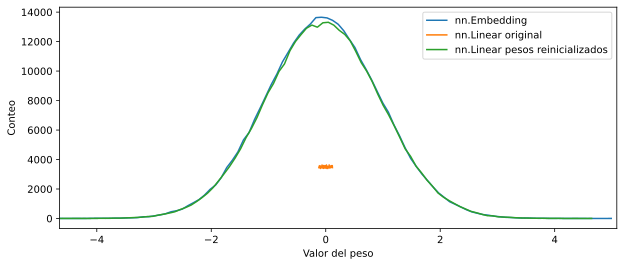

In [31]:
Lny, Lnx = np.histogram(Ln.weight.flatten().detach(), 100)

plt.figure(figsize=(10, 4))
plt.plot(Ex[:-1], Ey, label='nn.Embedding')
plt.plot(Lx[:-1], Ly, label='nn.Linear original')
plt.plot(Lnx[:-1], Lny, label='nn.Linear pesos reinicializados')

plt.gca().set(
    xlim=[np.min(Ex), np.max(Ex)],
    xlabel='Valor del peso',
    ylabel='Conteo'
)
plt.legend()
plt.show()

In [32]:
# Ambos se crean mediante nn.Parameter[cite: 8]
#??nn.Embedding[cite: 8]
#??nn.Linear[cite: 8]

Usa self.weight = Parameter, y esta es la clave de la matriz en la instancia de nn.Embedding.

En nn.Linear encontramos en su def __init__ cómo PyTorch inicializa esta instancia y, de nuevo, está llamando a self.weight = Parameter. Así que, en ambos casos, están llamando a las mismas funciones subyacentes de PyTorch para crear estas matrices asociadas que se integran en el grafo computacional.